# Loading Data

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

import random
import torch as th
from torchvision import transforms
import copy

# Simple Pytorch FFNN with hyperparameters controlling number of layers and hidden units per layer
class SimpleFFNN(th.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleFFNN, self).__init__()
        self.fc1 = th.nn.Linear(input_size, hidden_size)
        self.fc2 = th.nn.Linear(hidden_size, hidden_size)
        self.fc3 = th.nn.Linear(hidden_size, hidden_size)
        self.fc4 = th.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = th.relu(self.fc1(x))
        x = th.relu(self.fc2(x))
        x = th.relu(self.fc3(x))
        x = self.fc4(x)
        return x
# Function that returns empirical risk on data X,Y passed into it for a given model
def get_empirical_risk(model, X, Y):
    model.eval()
    with th.no_grad():
        outputs = model(X)
        criterion = th.nn.BCELoss()
        loss = criterion(outputs, Y)
    return loss.item()
def error_rate(model, X, Y, threshold=0.5):
    model.eval()
    with th.no_grad():
        probs = model(X)
        preds = (probs > threshold).float()
        errors = (preds != Y).float()
    return errors.mean().item()

def cross_validate(model, X, Y, loss_fn, k, seed=0):
    """
    model: an nn.Module instance (will be deep-copied per fold)
    data:  (X, Y) where X is [N, ...], Y is [N, ...] (or [N] for CE)
    k: number of folds (k can be N for LOOCV)
    Returns: (train_losses, val_losses) lists of floats, length k
    """
    th.manual_seed(seed)
    learning_rate = 0.1
    num_epochs = 100
    N = X.size(0)
    if not (1 <= k <= N):
        raise ValueError(f"k must be in [1, N], got k={k}, N={N}")
    # Make folds that cover all samples exactly once (works even if N % k != 0)
    indices = th.randperm(N, device=X.device) 
    folds = th.chunk(indices, k) # Attempts to split a tensor into the specified number of chunks. Each chunk is a view of the input tensor.
    tr_errs, val_errs = [], []
    for i in range(k):
        val_idx = folds[i] 
        train_idx = th.cat([folds[j] for j in range(k) if j != i], dim=0) # Join non validation samples
        X_tr, Y_tr = X[train_idx], Y[train_idx]
        X_va, Y_va = X[val_idx], Y[val_idx]

        # Fresh model for this fold
        m = copy.deepcopy(model)
        m.train()
        if th.cuda.is_available():
            m = m.cuda()
            X_tr = X_tr.cuda()
            Y_tr = Y_tr.cuda()
            X_va = X_va.cuda()
            Y_va = Y_va.cuda()
        # Minimal default choices
        opt = th.optim.SGD(m.parameters(), lr=1e-2)

        # train exactly like your original loop
        for epoch in range(num_epochs):
            m.train()
            opt.zero_grad()
            outputs = m(X_tr)
            loss = loss_fn(outputs, Y_tr)
            loss.backward()
            opt.step()

        tr_err = error_rate(m,X_tr, Y_tr)
        val_err = error_rate(m,X_va, Y_va)
        # print(f"Fold {i+1}/{k}, val loss = {val_loss:.4f}")
        val_errs.append(val_err)
        tr_errs.append(tr_err)
        if i == k - 1:
            trained_model = m  # keep last fold model
            del X_tr, Y_tr, X_va, Y_va
            th.cuda.empty_cache()
        else:
            del m
            del opt
            th.cuda.empty_cache()

    avgValErrs = sum(val_errs) / k
    avgTrainErrs = sum(tr_errs) / k
    # print(f"seed = {seed}, avg tr error = {avgTrainErrs:.4f}, avg val error = {avgValErrs:.4f}")
    return trained_model, avgValErrs, avgTrainErrs

def create_and_train_model(X, Y, model, seed=42):
    loss_fn = th.nn.BCELoss()
    trained_model, avgValErrs, avgTrainErrs = cross_validate(model, X, Y, loss_fn, k=5, seed=seed)
    return trained_model, avgValErrs, avgTrainErrs

def randomSeedSequence(numSeeds, rngSeed =42):
    random.seed(rngSeed)
    return [random.randint(0, 100000) for _ in range(numSeeds)]


def plot_validation_test_scores(val_scores, test_scores):
    import matplotlib.pyplot as plt
    plt.scatter(range(len(val_scores)), val_scores, label='Validation Loss')
    plt.scatter(range(len(test_scores)), test_scores, label='Test Loss')
    plt.xlabel('Model')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    numSeeds = 1
    rngSeed = 42

    transformToTensor = transforms.ToTensor() # To transform data to tensors
    # Create N samples of random d dimensional Feature vector uniformly sampled in [-1, 1]
    N_train = 100
    N_test = 1000
    d = 3
    X_train = th.rand(N_train, d) * 2 - 1
    Y_train = th.randint(0, 2, (N_train,2))
    Y_train = Y_train.float()
    X_test = th.rand(N_test, d) * 2 - 1
    Y_test = th.randint(0, 2, (N_test,2))
    Y_test = Y_test.float()
    seeds = randomSeedSequence(numSeeds,rngSeed=rngSeed)
    hidden_size = 50

    trainErrs, valErrs, testErrs = [], [], []
    for theSeed in enumerate(seeds):
        print(f"Training model with seed {theSeed[1]} ({theSeed[0]} of {numSeeds} Seeds)")
        model = SimpleFFNN(input_size=d, hidden_size=hidden_size, output_size=2)
        trainedModel, avgCVValErr, avgCVTrainErr = create_and_train_model(X_train, Y_train, model, seed=theSeed[1])
        trainErrs.append(avgCVTrainErr)
        valErrs.append(avgCVValErr)
        if th.cuda.is_available():
                trainedModel = trainedModel.cuda()
                X_test = X_test.cuda()
                Y_test = Y_test.cuda()
        testErrs.append(error_rate(trainedModel, X_test, Y_test))
print("Train acc:", 1 - sum(trainErrs) / len(trainErrs))
print("Test acc:", 1 - sum(testErrs) / len(testErrs))
    # plt.figure(figsize=(6,4))

    # plt.hist(valErrs, bins=20, density=True, alpha=0.6, label="Validation error")
    # plt.hist(testErrs, bins=20, density=True, alpha=0.6, label="Test error")

    # plt.xlabel("Error rate")
    # plt.ylabel("Probability density")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()


Training model with seed 83810 (0 of 1 Seeds)
Train acc: 0.46749999523162844
Test acc: 0.5039999783039093


# Multi processing

In [3]:
def run_one_seed(seed):
    model = SimpleFFNN(input_size=d, hidden_size=hidden_size, output_size=2)
    trained_model, avgCVValErr, avgCVTrainErr = create_and_train_model(
        X_train, Y_train, model, seed=seed
    )
    testErr = error_rate(trained_model, X_test, Y_test)
    return avgCVTrainErr, avgCVValErr, testErr
from multiprocessing import get_context
from tqdm import tqdm

ctx = get_context("fork")  # Linux only

with ctx.Pool(processes=ctx.cpu_count()) as pool:
    results = list(tqdm(pool.imap_unordered(run_one_seed, seeds), total=len(seeds)))

trainErrs, valErrs, testErrs = zip(*results)
trainErrs = list(trainErrs)
valErrs   = list(valErrs)
testErrs  = list(testErrs)


  0%|          | 0/10 [00:03<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

# Combining CSV Files and Visualising

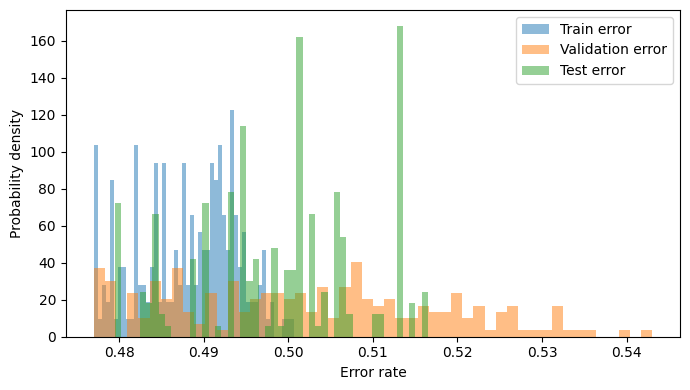

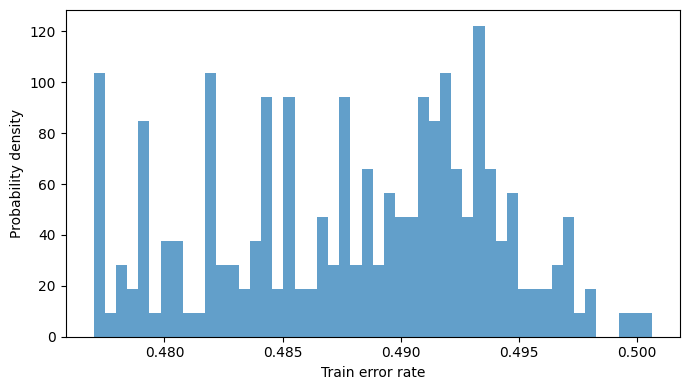

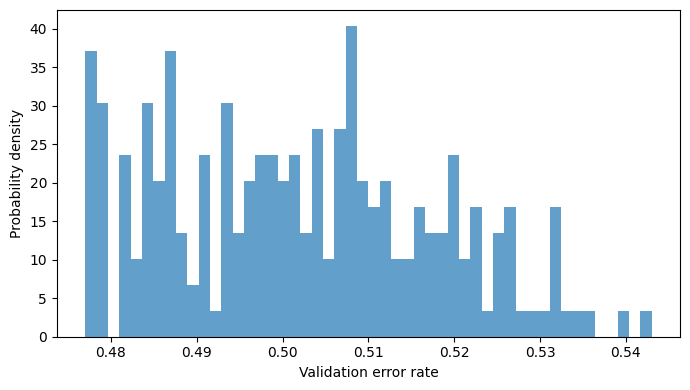

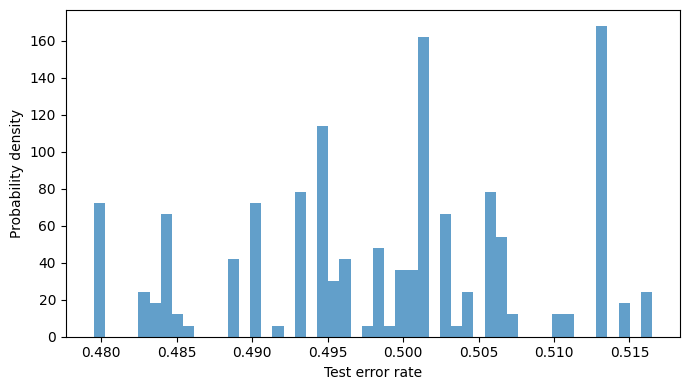

Loaded 15 files, total rows = 225


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

results_dir = "../results"

paths = sorted(glob.glob(os.path.join(results_dir, "*.csv")))
if not paths:
    raise FileNotFoundError(f"No CSV files found in ./{results_dir}/")

dfs = []
for p in paths:
    df = pd.read_csv(p)

    # support both formats:
    # 1) seed,train_error,val_error,test_error
    # 2) rngSeed,seed,train_error,val_error,test_error
    needed = {"train_error", "val_error", "test_error"}
    if not needed.issubset(df.columns):
        raise ValueError(f"{p} missing columns. Found: {list(df.columns)}")

    df["source_file"] = os.path.basename(p)
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

train = all_df["train_error"].astype(float).to_numpy()
val   = all_df["val_error"].astype(float).to_numpy()
test  = all_df["test_error"].astype(float).to_numpy()

# Overlaid PDFs
numBins = 50
plt.figure(figsize=(7, 4))
plt.hist(train, bins=numBins, density=True, alpha=0.5, label="Train error")
plt.hist(val,   bins=numBins, density=True, alpha=0.5, label="Validation error")
plt.hist(test,  bins=numBins, density=True, alpha=0.5, label="Test error")
plt.xlabel("Error rate")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.show()

# Separate PDFs (often easier to read)
plt.figure(figsize=(7, 4))
plt.hist(train, bins=numBins, density=True, alpha=0.7)
plt.xlabel("Train error rate")
plt.ylabel("Probability density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(val, bins=numBins, density=True, alpha=0.7)
plt.xlabel("Validation error rate")
plt.ylabel("Probability density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(test, bins=numBins, density=True, alpha=0.7)
plt.xlabel("Test error rate")
plt.ylabel("Probability density")
plt.tight_layout()
plt.show()

print(f"Loaded {len(paths)} files, total rows = {len(all_df)}")
